            Each week, you will apply the concepts of that week to your Integrated Capstone Project's dataset. In preparation for Milestone One, create a Jupyter Notebook that illustrates these lessons. There are no specific questions to answer in this notebook; the goal is to analyze the data using this week's methods and draw useful conclusions.

            For Week 6, the focus is decision trees and random forests. This notebook compares both methods on the Wisconsin and Brazil cancer datasets and looks at whether the random forest improves performance while controlling overfitting better than a single tree.
            


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT



PosixPath('/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone')

## Imports


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier

from src.load_data import load_brazil, load_wisconsin, split_X_y

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 80)
RANDOM_STATE = 42



            ## Wisconsin dataset

            Wisconsin is a good first check because the classes are fairly clean. I wanted to see whether a single tuned tree was already enough or whether the random forest still gave a noticeable gain.
            


In [3]:
df_w, target_w = load_wisconsin()
X_w, y_w = split_X_y(df_w, target_w)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w,
    y_w,
    test_size=0.2,
    stratify=y_w,
    random_state=RANDOM_STATE,
)

print("Wisconsin shape:", X_w.shape)
print("Positive class rate:", round(y_w.mean(), 3))



Wisconsin shape: (569, 30)
Positive class rate: 0.373


In [4]:
wisconsin_rows = []

wisconsin_tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 5, 10],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
wisconsin_tree_search.fit(Xw_train, yw_train)

wisconsin_tree_model = wisconsin_tree_search.best_estimator_
wisconsin_tree_pred = wisconsin_tree_model.predict(Xw_test)
wisconsin_tree_prob = wisconsin_tree_model.predict_proba(Xw_test)[:, 1]

wisconsin_rows.append(
    {
        "dataset": "Wisconsin",
        "model": "decision_tree",
        "accuracy": accuracy_score(yw_test, wisconsin_tree_pred),
        "precision": precision_score(yw_test, wisconsin_tree_pred),
        "recall": recall_score(yw_test, wisconsin_tree_pred),
        "f1": f1_score(yw_test, wisconsin_tree_pred),
        "roc_auc": roc_auc_score(yw_test, wisconsin_tree_prob),
        "pr_auc": average_precision_score(yw_test, wisconsin_tree_prob),
        "train_roc_auc": roc_auc_score(
            yw_train,
            wisconsin_tree_model.predict_proba(Xw_train)[:, 1],
        ),
        "cv_roc_auc": wisconsin_tree_search.best_score_,
        "best_params": wisconsin_tree_search.best_params_,
    }
)

wisconsin_forest_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {
        "n_estimators": [100, 200],
        "max_depth": [5, None],
        "min_samples_leaf": [1, 5],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
wisconsin_forest_search.fit(Xw_train, yw_train)

wisconsin_forest_model = wisconsin_forest_search.best_estimator_
wisconsin_forest_pred = wisconsin_forest_model.predict(Xw_test)
wisconsin_forest_prob = wisconsin_forest_model.predict_proba(Xw_test)[:, 1]

wisconsin_rows.append(
    {
        "dataset": "Wisconsin",
        "model": "random_forest",
        "accuracy": accuracy_score(yw_test, wisconsin_forest_pred),
        "precision": precision_score(yw_test, wisconsin_forest_pred),
        "recall": recall_score(yw_test, wisconsin_forest_pred),
        "f1": f1_score(yw_test, wisconsin_forest_pred),
        "roc_auc": roc_auc_score(yw_test, wisconsin_forest_prob),
        "pr_auc": average_precision_score(yw_test, wisconsin_forest_prob),
        "train_roc_auc": roc_auc_score(
            yw_train,
            wisconsin_forest_model.predict_proba(Xw_train)[:, 1],
        ),
        "cv_roc_auc": wisconsin_forest_search.best_score_,
        "best_params": wisconsin_forest_search.best_params_,
    }
)

wisconsin_results = pd.DataFrame(wisconsin_rows)
wisconsin_results.round(4)



,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_roc_auc,cv_roc_auc,best_params
0,Wisconsin,decision_tree,0.9123,1.0,0.7619,0.8649,0.9688,0.9533,0.9929,0.9559,"{'max_depth': 5, 'min_samples_leaf': 10}"
1,Wisconsin,random_forest,0.9737,1.0,0.9286,0.9630,0.9929,0.9893,1.0000,0.9889,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}"


            Wisconsin still favored the random forest. The single tree worked reasonably well, but the forest pushed the metrics higher and looked more stable based on the cross-validated ROC-AUC.
            


            ## Brazil dataset

            Brazil is tougher and more imbalanced, so I used the same 8,000-row sample as Week 5 to keep the notebook runnable. This dataset is also the more interesting one for thinking about overfitting and feature importance.
            


In [5]:
df_b, target_b = load_brazil(sample_size=8000, random_state=RANDOM_STATE)
X_b, y_b = split_X_y(df_b, target_b)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b,
    y_b,
    test_size=0.2,
    stratify=y_b,
    random_state=RANDOM_STATE,
)

print("Brazil sample shape:", X_b.shape)
print("Positive class rate:", round(y_b.mean(), 3))



Brazil sample shape: (8000, 39)
Positive class rate: 0.07


In [6]:
brazil_rows = []

brazil_tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 5, 10],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
brazil_tree_search.fit(Xb_train, yb_train)

brazil_tree_model = brazil_tree_search.best_estimator_
brazil_tree_pred = brazil_tree_model.predict(Xb_test)
brazil_tree_prob = brazil_tree_model.predict_proba(Xb_test)[:, 1]

brazil_rows.append(
    {
        "dataset": "Brazil",
        "model": "decision_tree",
        "accuracy": accuracy_score(yb_test, brazil_tree_pred),
        "precision": precision_score(yb_test, brazil_tree_pred, zero_division=0),
        "recall": recall_score(yb_test, brazil_tree_pred, zero_division=0),
        "f1": f1_score(yb_test, brazil_tree_pred, zero_division=0),
        "roc_auc": roc_auc_score(yb_test, brazil_tree_prob),
        "pr_auc": average_precision_score(yb_test, brazil_tree_prob),
        "train_roc_auc": roc_auc_score(
            yb_train,
            brazil_tree_model.predict_proba(Xb_train)[:, 1],
        ),
        "cv_roc_auc": brazil_tree_search.best_score_,
        "best_params": brazil_tree_search.best_params_,
    }
)

brazil_forest_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {
        "n_estimators": [100, 200],
        "max_depth": [5, None],
        "min_samples_leaf": [1, 5],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
brazil_forest_search.fit(Xb_train, yb_train)

brazil_forest_model = brazil_forest_search.best_estimator_
brazil_forest_pred = brazil_forest_model.predict(Xb_test)
brazil_forest_prob = brazil_forest_model.predict_proba(Xb_test)[:, 1]

brazil_rows.append(
    {
        "dataset": "Brazil",
        "model": "random_forest",
        "accuracy": accuracy_score(yb_test, brazil_forest_pred),
        "precision": precision_score(yb_test, brazil_forest_pred, zero_division=0),
        "recall": recall_score(yb_test, brazil_forest_pred, zero_division=0),
        "f1": f1_score(yb_test, brazil_forest_pred, zero_division=0),
        "roc_auc": roc_auc_score(yb_test, brazil_forest_prob),
        "pr_auc": average_precision_score(yb_test, brazil_forest_prob),
        "train_roc_auc": roc_auc_score(
            yb_train,
            brazil_forest_model.predict_proba(Xb_train)[:, 1],
        ),
        "cv_roc_auc": brazil_forest_search.best_score_,
        "best_params": brazil_forest_search.best_params_,
    }
)

brazil_results = pd.DataFrame(brazil_rows)
brazil_results.round(4)



,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_roc_auc,cv_roc_auc,best_params
0,Brazil,decision_tree,0.9356,0.6042,0.2566,0.3602,0.8840,0.4648,0.9129,0.8856,"{'max_depth': 5, 'min_samples_leaf': 10}"
1,Brazil,random_forest,0.9406,0.6875,0.2920,0.4099,0.9363,0.5429,0.9733,0.9339,"{'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}"


            Brazil made the tree-vs-forest difference easier to see. Accuracy stayed fairly high for both models, but the random forest did better on ROC-AUC, PR-AUC, and F1, which makes it more useful for the harder minority-class problem.
            


## Combined comparison


In [7]:
week6_results = pd.concat([wisconsin_results, brazil_results], ignore_index=True)
week6_results.round(4)



,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_roc_auc,cv_roc_auc,best_params
0,Wisconsin,decision_tree,0.9123,1.0000,0.7619,0.8649,0.9688,0.9533,0.9929,0.9559,"{'max_depth': 5, 'min_samples_leaf': 10}"
1,Wisconsin,random_forest,0.9737,1.0000,0.9286,0.9630,0.9929,0.9893,1.0000,0.9889,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}"
2,Brazil,decision_tree,0.9356,0.6042,0.2566,0.3602,0.8840,0.4648,0.9129,0.8856,"{'max_depth': 5, 'min_samples_leaf': 10}"
3,Brazil,random_forest,0.9406,0.6875,0.2920,0.4099,0.9363,0.5429,0.9733,0.9339,"{'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}"


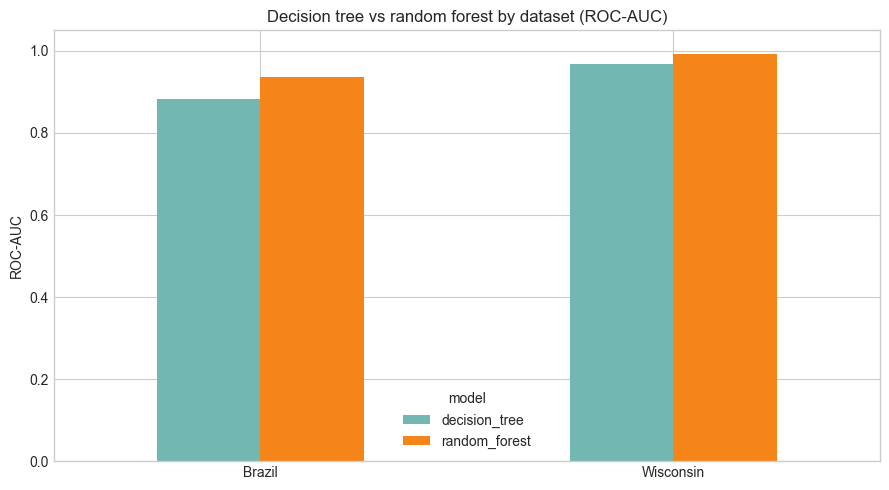

In [8]:
roc_plot = week6_results.pivot(index="dataset", columns="model", values="roc_auc")
ax = roc_plot.plot(kind="bar", figsize=(9, 5), color=["#72b7b2", "#f58518"], rot=0)
ax.set_title("Decision tree vs random forest by dataset (ROC-AUC)")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()



## Brazil random forest feature importance


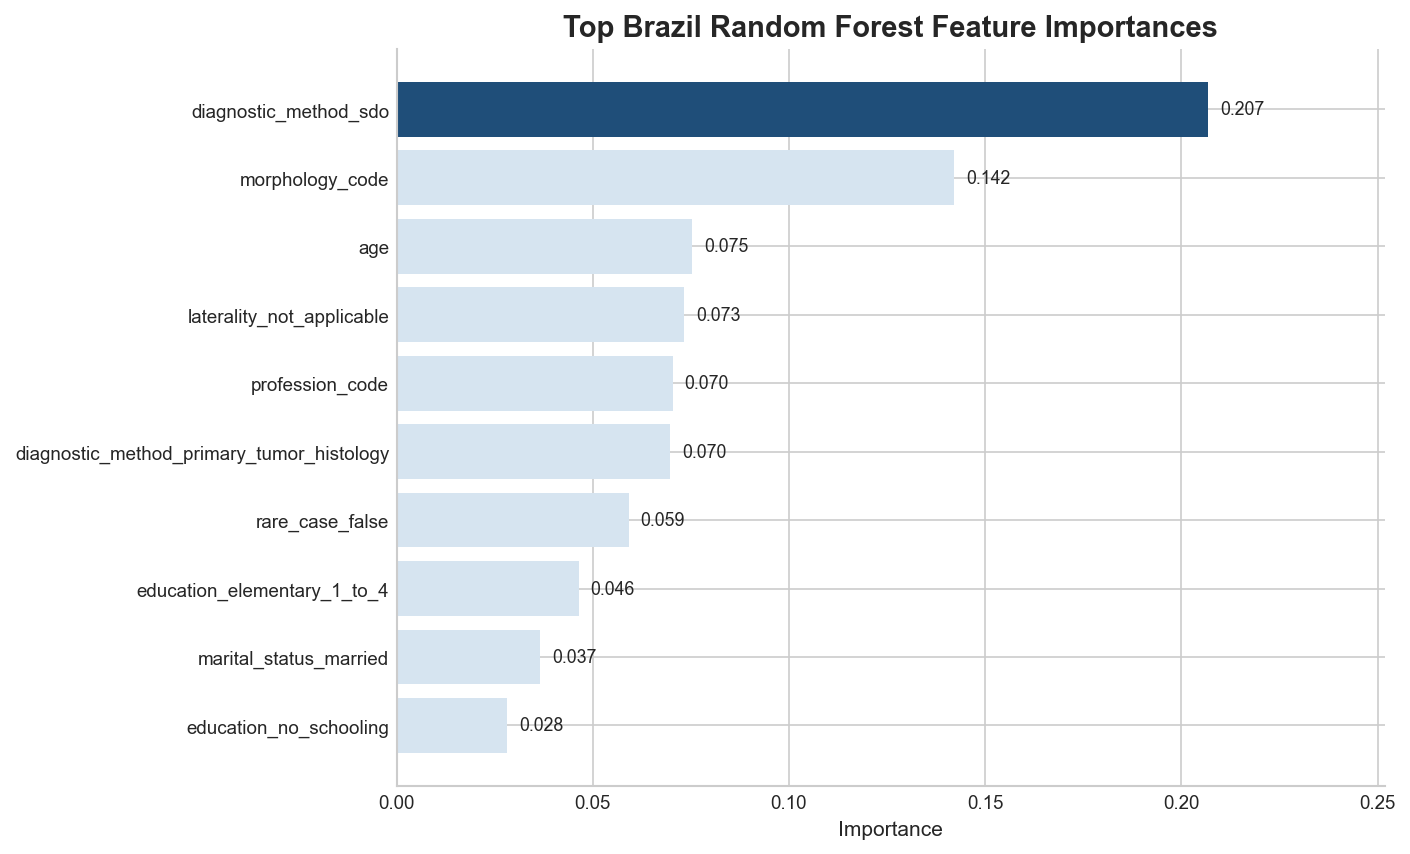

diagnostic_method_sdo                        0.2069
morphology_code                              0.1421
age                                          0.0753
laterality_not_applicable                    0.0733
profession_code                              0.0704
diagnostic_method_primary_tumor_histology    0.0698
rare_case_false                              0.0591
education_elementary_1_to_4                  0.0464
marital_status_married                       0.0366
education_no_schooling                       0.0281
dtype: float64

In [9]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

brazil_feature_importance = (
    pd.Series(brazil_forest_model.feature_importances_, index=X_b.columns)
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
colors = ["#D6E4F0"] * len(brazil_feature_importance)
colors[-1] = "#1F4E79"
ax.barh(brazil_feature_importance.index, brazil_feature_importance.values, color=colors)
ax.set_title("Top Brazil Random Forest Feature Importances", fontsize=14, weight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for y_pos, value in enumerate(brazil_feature_importance.values):
    ax.text(value + 0.003, y_pos, f"{value:.3f}", va="center", fontsize=8.5)
ax.set_xlim(0, brazil_feature_importance.max() + 0.045)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig06_brazil_rf_feature_importance.png", bbox_inches="tight", facecolor="white")
plt.show()

brazil_feature_importance.sort_values(ascending=False).round(4)


            The importance plot suggests that the forest relied most on a mix of diagnostic, morphology, age, and laterality variables rather than on one single dominant field. That is useful because it gives the model a more interpretable story than a black-box result with no feature signal at all.
            


            ## Week 6 takeaway

            For both datasets, the random forest outperformed the single decision tree. On Wisconsin, the gain was moderate because the problem is already fairly easy, but the forest still improved ROC-AUC and recall.

            On Brazil, the difference mattered more. The tuned decision tree was limited enough to avoid obvious overfitting, but it still missed a lot of positive cases. The random forest improved ROC-AUC, PR-AUC, and F1 while also giving a usable feature-importance summary, so this feels like a strong Week 6 candidate for the deeper Milestone 1 discussion.
            
